In [3]:
# csv files
import pandas as pd
# Read the data
df_train=pd.read_csv('../data_ingestion/data_csvs/train.csv')
df_localizers=pd.read_csv('../data_ingestion/data_csvs/train_localizers.csv')

### df_train is the main info of the labled classes

In [6]:
train_cols=df_train.columns

In [11]:
print(f"==Columns in train dataset==")
for col in train_cols:
    print(f'{col}------{df_train[col].dtype}')

==Columns in train dataset==
SeriesInstanceUID------object
PatientAge------int64
PatientSex------object
Modality------object
Left Infraclinoid Internal Carotid Artery------int64
Right Infraclinoid Internal Carotid Artery------int64
Left Supraclinoid Internal Carotid Artery------int64
Right Supraclinoid Internal Carotid Artery------int64
Left Middle Cerebral Artery------int64
Right Middle Cerebral Artery------int64
Anterior Communicating Artery------int64
Left Anterior Cerebral Artery------int64
Right Anterior Cerebral Artery------int64
Left Posterior Communicating Artery------int64
Right Posterior Communicating Artery------int64
Basilar Tip------int64
Other Posterior Circulation------int64
Aneurysm Present------int64


In [13]:
print(f"Length of dataset: {len(df_train)}")

Length of dataset: 4405


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [ ]:
# required transforms
# 1. Patient age --> 1.4 power
# 2. Gender to --> numerical
# 3. Modality --> numerical
# 4. Series remove while training

Text(0.5, 1.0, 'Age QQ Plot')

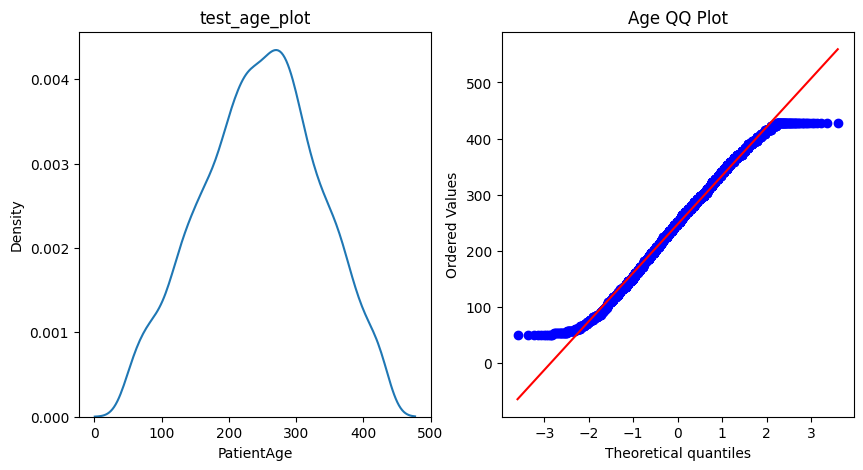

In [ ]:
degree=1.4
plt.figure(figsize=(10,5))
test_age=(df_train['PatientAge'])**degree

plt.subplot(1,2,1)
sns.kdeplot((test_age))
plt.title('test_age_plot')

plt.subplot(1,2,2)
stats.probplot(test_age, dist="norm", plot=plt)
plt.title('Age QQ Plot')

Text(0.5, 1.0, 'Age distribution')

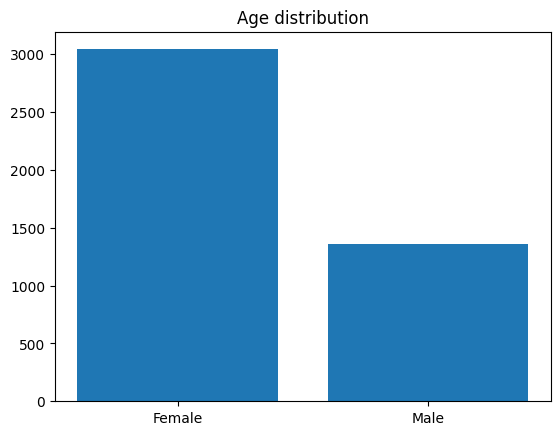

In [68]:
patient_age=df_train['PatientSex'].value_counts()
plt.bar(patient_age.index,patient_age)
plt.title('Age distribution')

Text(0.5, 1.0, 'Modality')

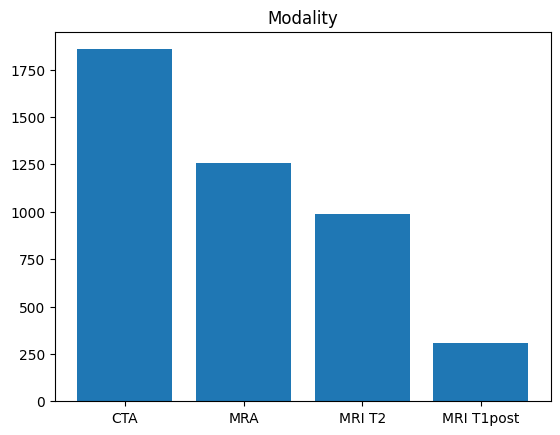

In [72]:
# modality
modality=df_train['Modality'].value_counts()
plt.bar(modality.index,modality,)
plt.title('Modality')

In [ ]:
# Modality vs anuerysm
df_train.groupby(['Modality', 'Aneurysm Present']).size().unstack(fill_value=0)

Aneurysm Present,0,1
Modality,,
CTA,860,997
MRA,699,557
MRI T1post,228,78
MRI T2,725,261


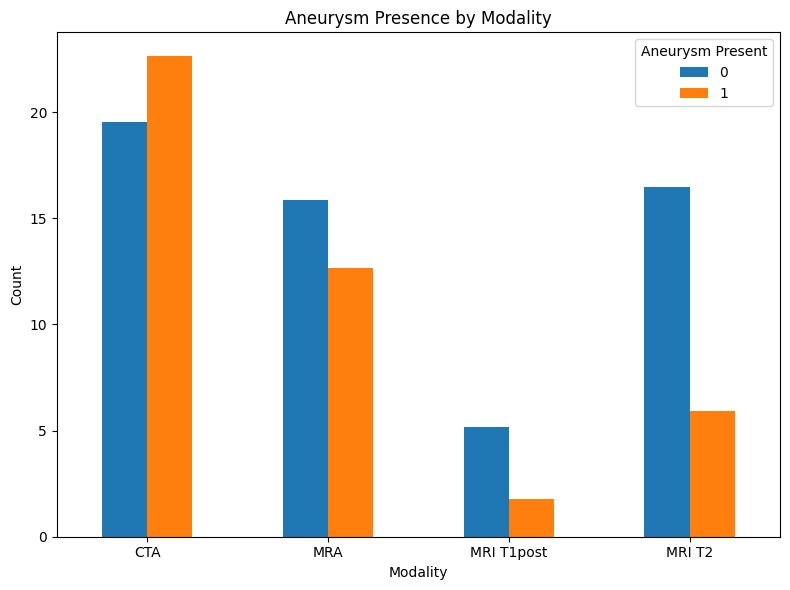

In [119]:
# Sample aggregation
df_counts = df_train.groupby(['Modality', 'Aneurysm Present']).size().unstack(fill_value=0)
df_counts=(df_counts/len(df_train))*100
# Plot
df_counts.plot(kind='bar', figsize=(8,6))
plt.title('Aneurysm Presence by Modality')
plt.xlabel('Modality')
plt.ylabel('Count')
plt.legend(title='Aneurysm Present')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [120]:
df_train.columns

Index(['SeriesInstanceUID', 'PatientAge', 'PatientSex', 'Modality',
       'Left Infraclinoid Internal Carotid Artery',
       'Right Infraclinoid Internal Carotid Artery',
       'Left Supraclinoid Internal Carotid Artery',
       'Right Supraclinoid Internal Carotid Artery',
       'Left Middle Cerebral Artery', 'Right Middle Cerebral Artery',
       'Anterior Communicating Artery', 'Left Anterior Cerebral Artery',
       'Right Anterior Cerebral Artery', 'Left Posterior Communicating Artery',
       'Right Posterior Communicating Artery', 'Basilar Tip',
       'Other Posterior Circulation', 'Aneurysm Present'],
      dtype='object')

In [121]:
# region analysis
regions=df_train.columns[4:-1]

In [124]:
df_train[regions[0]].value_counts()[0]

np.int64(4326)

In [131]:
region_dict = {'region': [], 'Present': [], 'Absent': []}
for region in regions:
    region_count = df_train[region].value_counts()
    present = region_count[0]
    absent = region_count[1]
    region_dict['region'].append(region)
    region_dict['Present'].append(present)
    region_dict['Absent'].append(absent)

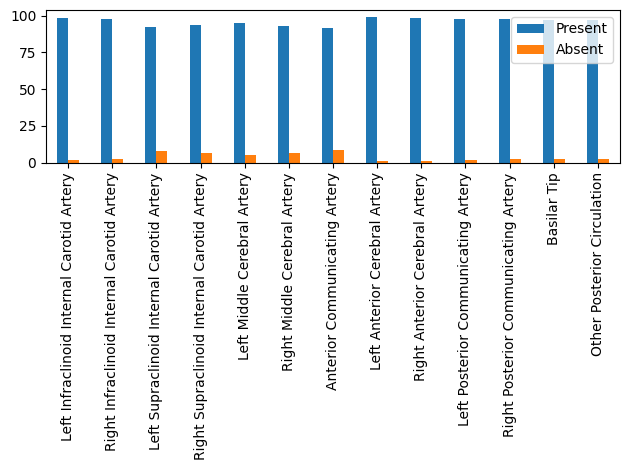

In [140]:
region_df=pd.DataFrame(region_dict)
region_df[['Present', 'Absent']] = (region_df[['Present', 'Absent']] / len(df_train)) * 100
ax = region_df.plot(kind='bar')
plt.xticks(ticks=range(len(region_df['region'])), labels=region_df['region'], rotation=90)
plt.tight_layout()

In [141]:
region_df

,region,Present,Absent
0,Left Infraclinoid Internal Carotid Artery,98.206583,1.793417
1,Right Infraclinoid Internal Carotid Artery,97.752554,2.247446
2,Left Supraclinoid Internal Carotid Artery,92.281498,7.718502
3,Right Supraclinoid Internal Carotid Artery,93.598184,6.401816
4,Left Middle Cerebral Artery,95.005675,4.994325
5,Right Middle Cerebral Artery,93.212259,6.787741
6,Anterior Communicating Artery,91.691260,8.308740
7,Left Anterior Cerebral Artery,98.955732,1.044268
8,Right Anterior Cerebral Artery,98.728717,1.271283
9,Left Posterior Communicating Artery,98.024972,1.975028


In [144]:
df_train['Aneurysm Present'].value_counts()
# Therefore although anuerysm is present 50 % overall still region percentages are higher indicating that while a presence of anuerysm is there , it is multi regional

Aneurysm Present
0    2512
1    1893
Name: count, dtype: int64

In [142]:
df_localizers.columns

Index(['SeriesInstanceUID', 'SOPInstanceUID', 'coordinates', 'location'], dtype='object')